# Notebook 03 — Correlation Analysis & Machine Learning

**Reads from `outputs/` (produced by Notebook 01):**
- `dfm_merged.csv`, `metadata_numerical.csv`, `wide_scaled_imputed.csv`

**Analyses:**
1. Correlation heatmaps (ALS-only, Plasma & CSF) with significance masking
2. Top correlated pairs — scatter grids + PPT export
3. Cross-platform concordance heatmaps (if configured)
4. Random Forest classification (ALS vs HC) with feature importances
5. Feature clustering: dendrograms + clustered heatmaps
6. Alluvial plots: cluster reassignment between HC and ALS

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import io, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import pearsonr
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA

from config import *
from utils import (
    compute_corr_and_p, compute_corr_matrix, build_feature_matrix,
    clean_label, clean_labels, plot_corr_heatmap
)

In [2]:
dfm = pd.read_csv(OUTPUT_DIR / "dfm_merged.csv")
metadata_numerical = pd.read_csv(OUTPUT_DIR / "metadata_numerical.csv")
final_wide_imputed = pd.read_csv(OUTPUT_DIR / "wide_scaled_imputed.csv")

# Column splits
meta_col_set = set(metadata_numerical.columns)
all_cols = [c for c in dfm.columns if c not in {ID_COL, GROUP_COL, "Dx.Mutation", "Dx.Detailed"} | set(META_NUMERIC_KEEP)]
# Actually let's be more careful:
exclude_set = {ID_COL, GROUP_COL, "Dx.Mutation", "Dx.Detailed"} | set(META_NUMERIC_KEEP)
analyte_cols = [c for c in dfm.columns if c not in exclude_set and c not in meta_col_set]
plasma_cols = [c for c in analyte_cols if c.endswith("_Plasma")]
csf_cols    = [c for c in analyte_cols if c.endswith("_CSF")]

# Subsets
df_als = dfm[dfm[GROUP_COL] == CASE_LABEL].copy()
df_hc  = dfm[dfm[GROUP_COL] == CONTROL_LABEL].copy()
df_use = dfm[dfm[GROUP_COL].isin([CASE_LABEL, CONTROL_LABEL])].copy()

print(f"ALS: {len(df_als)} | HC: {len(df_hc)} | Total: {len(df_use)}")
print(f"Plasma cols: {len(plasma_cols)} | CSF cols: {len(csf_cols)}")

ALS: 50 | HC: 30 | Total: 80
Plasma cols: 21 | CSF cols: 16


## 1 · Correlation Heatmaps (ALS-only)

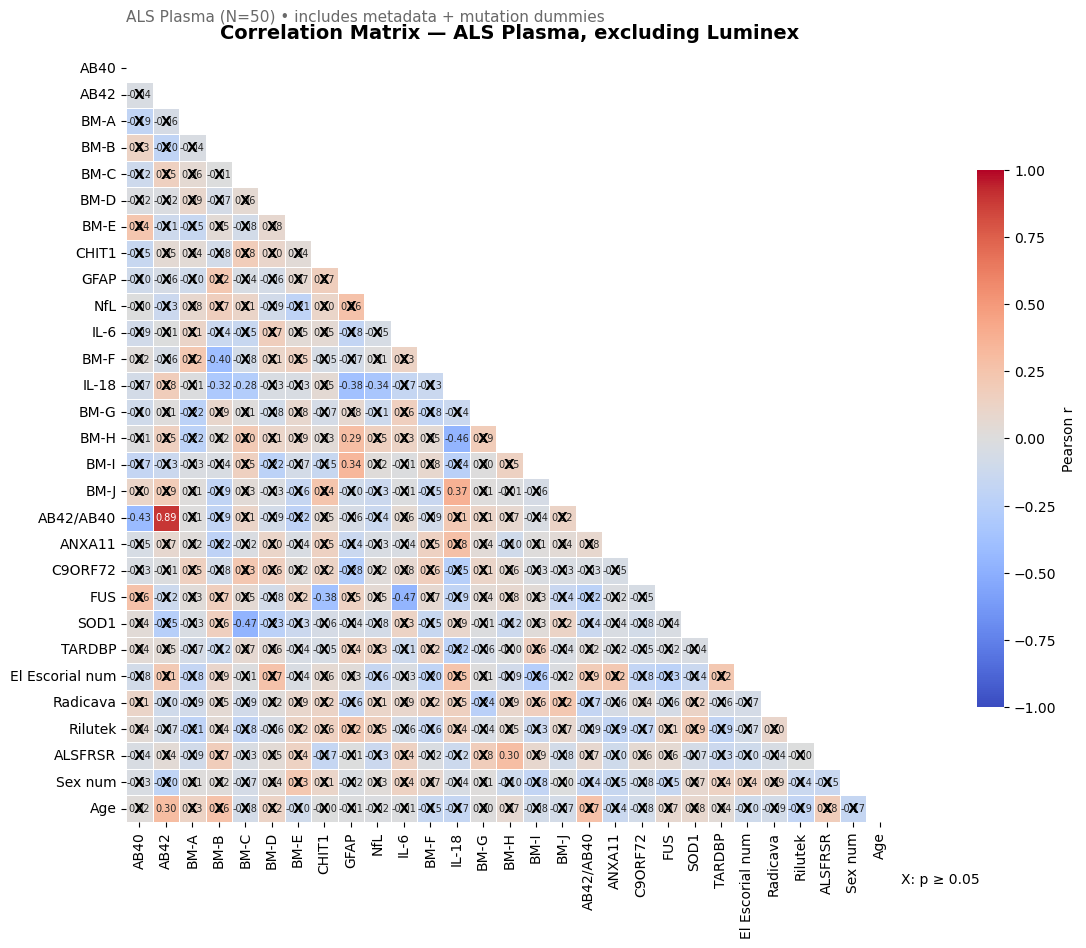

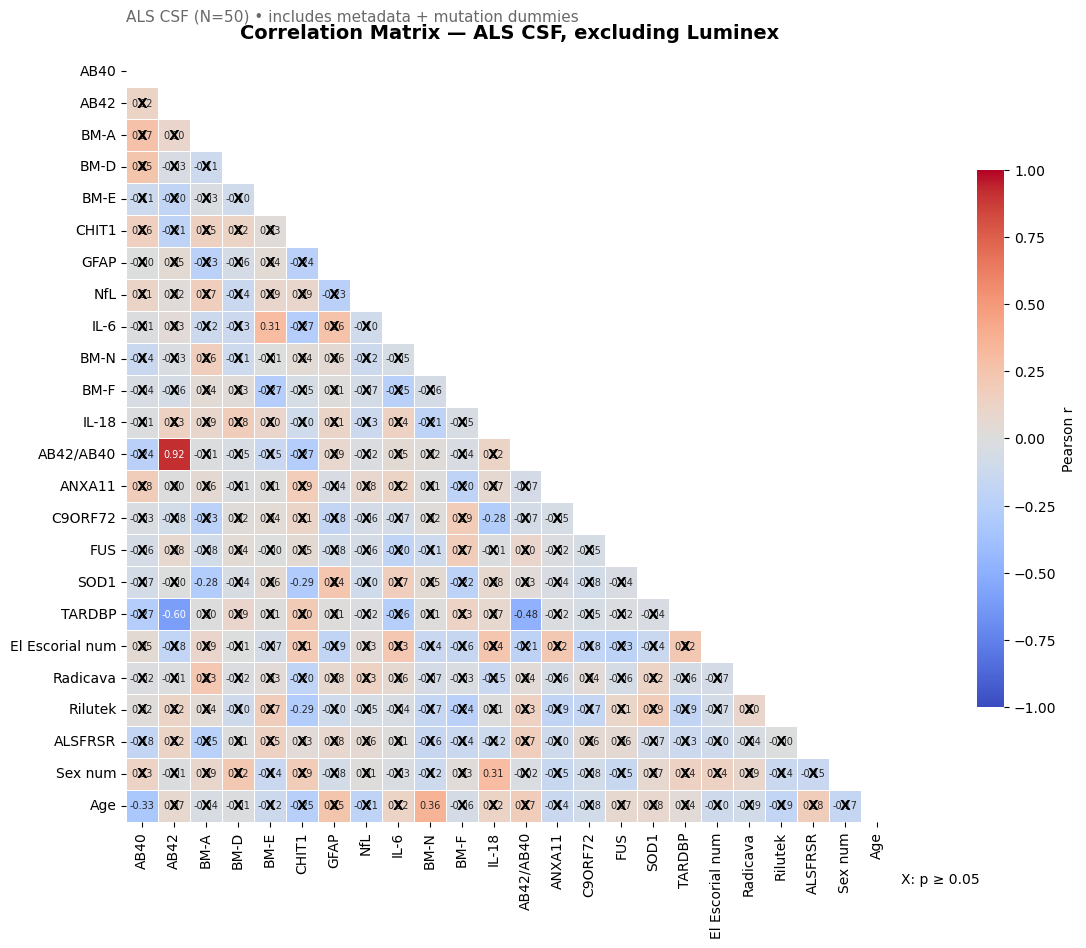

In [3]:
X_plasma = build_feature_matrix(df_als, plasma_cols, mutation_col=MUTATION_COL,
                                 meta_numeric_keep=META_NUMERIC_KEEP,
                                 exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)
X_csf = build_feature_matrix(df_als, csf_cols, mutation_col=MUTATION_COL,
                              meta_numeric_keep=META_NUMERIC_KEEP,
                              exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)

if X_plasma.shape[1] >= 2:
    corr_p, pmat_p = compute_corr_and_p(X_plasma)
    excl = f", excluding {EXCLUDE_PLATFORM_KEYWORD.title()}" if EXCLUDE_PLATFORM_KEYWORD else ""
    plot_corr_heatmap(
        corr_p, pmat_p,
        title=f"Correlation Matrix — {CASE_LABEL} Plasma{excl}",
        subtitle=f"{CASE_LABEL} Plasma (N={len(df_als)}) • includes metadata + mutation dummies",
    )
else:
    print("Not enough Plasma variables for correlation.")

if X_csf.shape[1] >= 2:
    corr_c, pmat_c = compute_corr_and_p(X_csf)
    plot_corr_heatmap(
        corr_c, pmat_c,
        title=f"Correlation Matrix — {CASE_LABEL} CSF{excl}",
        subtitle=f"{CASE_LABEL} CSF (N={len(df_als)}) • includes metadata + mutation dummies",
    )
else:
    print("Not enough CSF variables for correlation.")

## 2 · Top Correlated Pairs — Scatter Plots

In [4]:
def get_top_pairs(corr, pmat, cols, top_k=20, alpha=ALPHA):
    """Extract top-k significant pairwise correlations by |r|."""
    if corr is None or pmat is None or len(cols) < 2:
        return pd.DataFrame(columns=["x", "y", "r", "p", "abs_r"])
    keep = [c for c in cols if c in corr.columns]
    if len(keep) < 2:
        return pd.DataFrame(columns=["x", "y", "r", "p", "abs_r"])
    corr_sub = corr.loc[keep, keep]
    pmat_sub = pmat.loc[keep, keep]
    pairs = []
    col_list = list(corr_sub.columns)
    for i in range(len(col_list)):
        for j in range(i+1, len(col_list)):
            a, b = col_list[i], col_list[j]
            r = corr_sub.loc[a, b]
            p = pmat_sub.loc[a, b]
            if pd.notna(r) and pd.notna(p) and p < alpha:
                pairs.append((a, b, r, p, abs(r)))
    if not pairs:
        return pd.DataFrame(columns=["x", "y", "r", "p", "abs_r"])
    df_pairs = pd.DataFrame(pairs, columns=["x", "y", "r", "p", "abs_r"])
    return df_pairs.sort_values("abs_r", ascending=False).head(top_k).reset_index(drop=True)


def make_scatter_grid(df, top_pairs, title_prefix, plots_per_fig=4, figsize=(10, 8)):
    """Create 2×2 scatter grids for top correlated pairs."""
    figs = []
    if top_pairs.empty:
        print(f"{title_prefix}: No significant pairs found.")
        return figs
    n = len(top_pairs)
    nrows, ncols = 2, 2

    for start in range(0, n, plots_per_fig):
        end = min(start + plots_per_fig, n)
        chunk = top_pairs.iloc[start:end]
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
        axes_flat = np.atleast_2d(axes).flatten()
        for ax in axes_flat:
            ax.axis("off")

        for k, (_, row) in enumerate(chunk.iterrows()):
            ax = axes_flat[k]
            xname, yname, r, p = row["x"], row["y"], row["r"], row["p"]
            x = pd.to_numeric(df[xname], errors="coerce")
            y = pd.to_numeric(df[yname], errors="coerce")
            mask = x.notna() & y.notna()
            xv, yv = x[mask].values, y[mask].values
            n_pairs = len(xv)
            ax.scatter(xv, yv, s=22, alpha=0.7, color="steelblue", edgecolor="white", linewidth=0.5)

            r2 = np.nan
            if n_pairs >= 2 and np.std(xv) > 0:
                m, b = np.polyfit(xv, yv, 1)
                xs = np.linspace(xv.min(), xv.max(), 100)
                ax.plot(xs, m * xs + b, color="crimson", lw=1.5)
                r_calc = r if pd.notna(r) else pearsonr(xv, yv)[0]
                if pd.notna(r_calc):
                    r2 = r_calc ** 2

            ax.set_title(f"{clean_label(xname)} vs {clean_label(yname)}\n"
                         f"r={r:.2f}, R2={r2:.2f}  p={p:.2g}, n={n_pairs}", fontsize=9)
            ax.set_xlabel(clean_label(xname), fontsize=8)
            ax.set_ylabel(clean_label(yname), fontsize=8)
            ax.tick_params(axis="both", labelsize=8)
            ax.grid(alpha=0.2)
            ax.axis("on")

        fig.suptitle(f"{title_prefix}: Top correlations ({start+1}–{end})", fontsize=12, y=0.98)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        figs.append(fig)
        plt.show()
    return figs


Top Plasma pairs (by |r|, p < 0.05):
                       x                    y         r             p  \
0      ELISA_AB42_Plasma     AB42/AB40_Plasma  0.893462  2.630628e-18   
1    Uplex1_IL-18_Plasma   Vplex1_BM-H_Plasma -0.462425  7.222448e-04   
2      ELISA_AB40_Plasma     AB42/AB40_Plasma -0.426064  2.035381e-03   
3      ELISA_BM-B_Plasma   Uplex1_BM-F_Plasma -0.400337  3.967200e-03   
4  Quanterix_GFAP_Plasma  Uplex1_IL-18_Plasma -0.376477  7.045302e-03   
5    Uplex1_IL-18_Plasma   Vplex1_BM-J_Plasma  0.372296  7.758439e-03   
6  Quanterix_GFAP_Plasma   Vplex1_BM-I_Plasma  0.342517  1.489794e-02   
7   Quanterix_NfL_Plasma  Uplex1_IL-18_Plasma -0.342441  1.492158e-02   
8      ELISA_BM-B_Plasma  Uplex1_IL-18_Plasma -0.318990  2.395213e-02   
9  Quanterix_GFAP_Plasma   Vplex1_BM-H_Plasma  0.289319  4.156409e-02   

      abs_r  
0  0.893462  
1  0.462425  
2  0.426064  
3  0.400337  
4  0.376477  
5  0.372296  
6  0.342517  
7  0.342441  
8  0.318990  
9  0.289319  


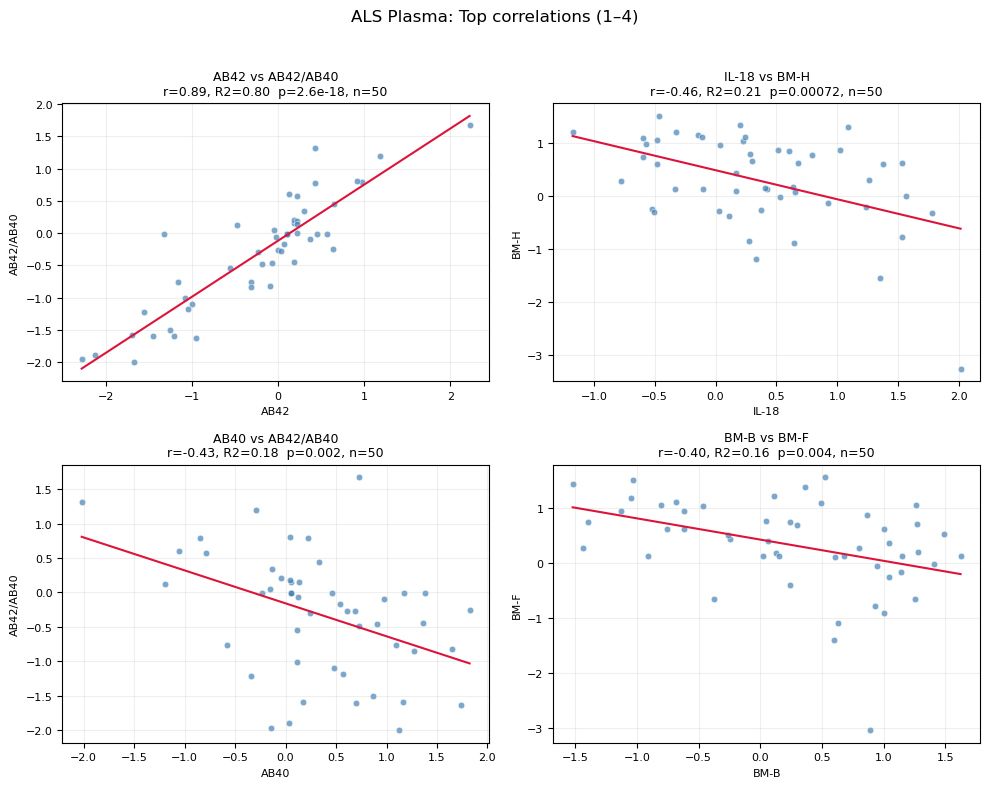

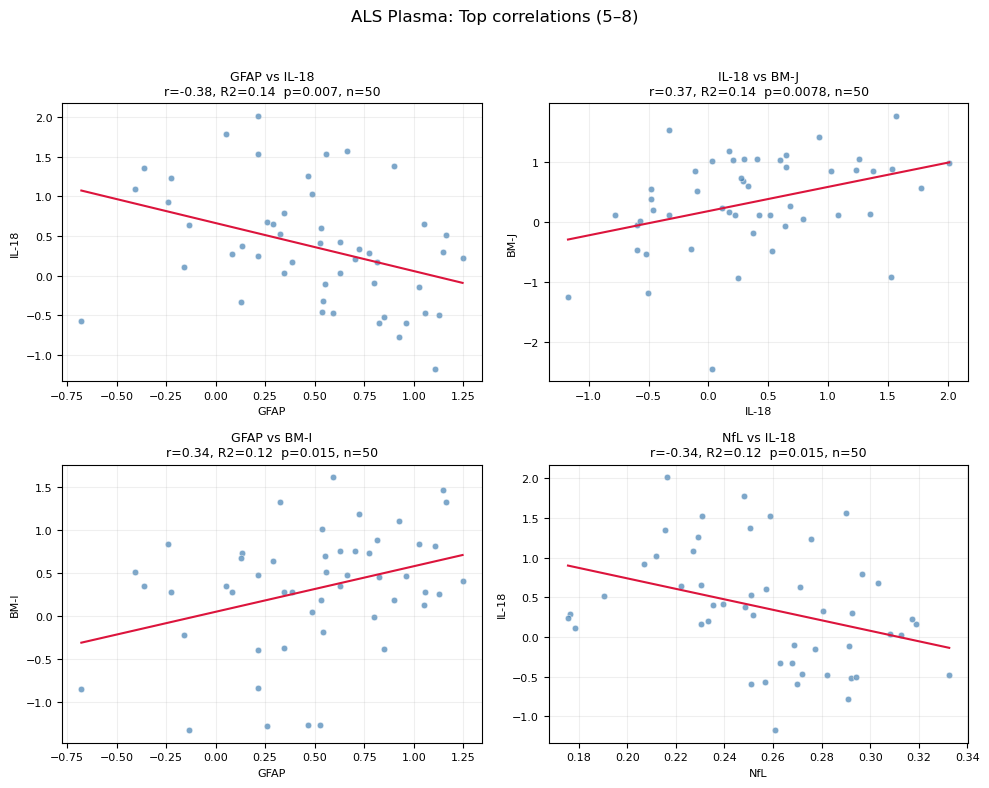

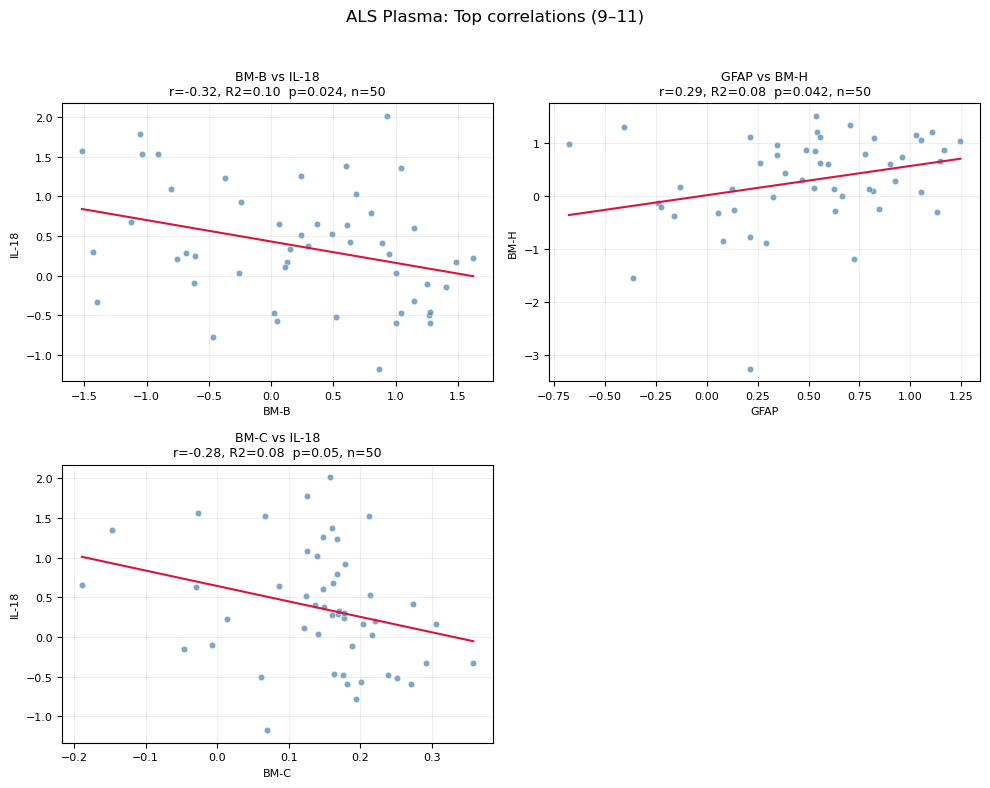


Top CSF pairs (by |r|, p < 0.05):
                x                y         r             p     abs_r
0  ELISA_AB42_CSF    AB42/AB40_CSF  0.918773  5.244053e-21  0.918773
1  ELISA_BM-E_CSF  Splex1_IL-6_CSF  0.312122  2.733773e-02  0.312122


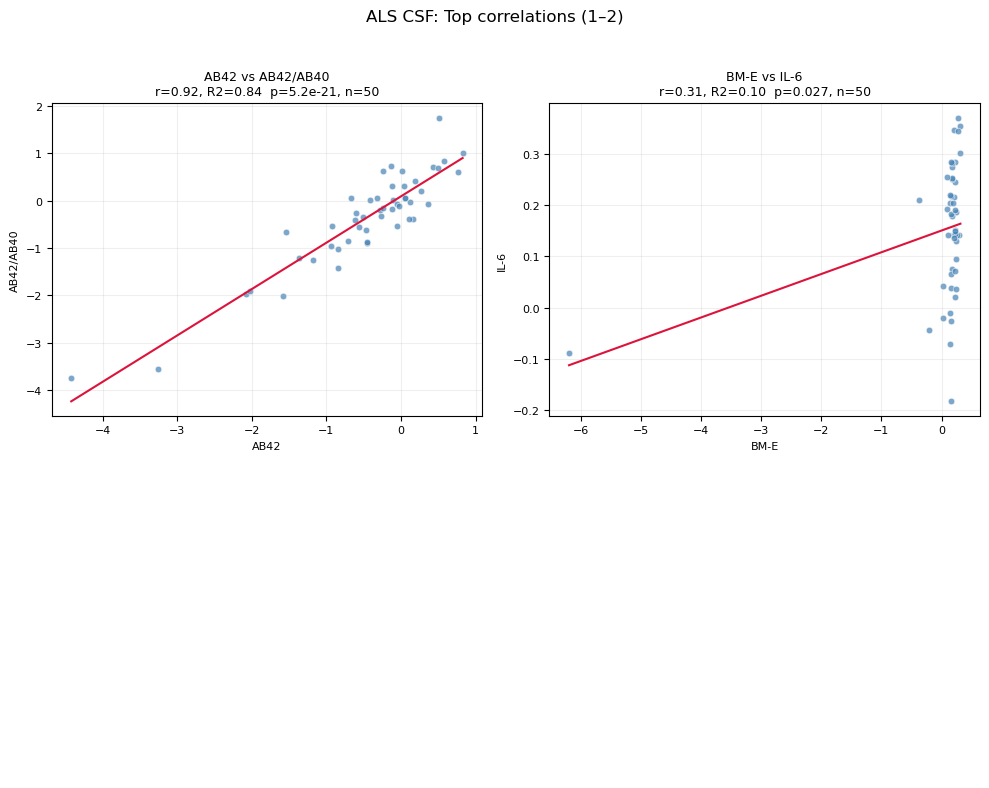

In [5]:
if X_plasma.shape[1] >= 2:
    plasma_analyte_cols = [c for c in X_plasma.columns if c in plasma_cols]
    top20_plasma = get_top_pairs(corr_p, pmat_p, cols=plasma_analyte_cols)
    print(f"\nTop Plasma pairs (by |r|, p < {ALPHA}):")
    print(top20_plasma.head(10))
    figs_plasma = make_scatter_grid(df_als, top20_plasma, title_prefix=f"{CASE_LABEL} Plasma")
else:
    top20_plasma = pd.DataFrame()
    figs_plasma = []

if X_csf.shape[1] >= 2:
    csf_analyte_cols = [c for c in X_csf.columns if c in csf_cols]
    top20_csf = get_top_pairs(corr_c, pmat_c, cols=csf_analyte_cols)
    print(f"\nTop CSF pairs (by |r|, p < {ALPHA}):")
    print(top20_csf.head(10))
    figs_csf = make_scatter_grid(df_als, top20_csf, title_prefix=f"{CASE_LABEL} CSF")
else:
    top20_csf = pd.DataFrame()
    figs_csf = []

## 3 · Cross-Platform Concordance (Optional)

If you have Luminex ↔ other-platform pairs configured in `config.py`,
this section computes pairwise correlations and plots a heatmap.

In [6]:
def compute_pairwise_r_and_p(df, pairs, min_pairs=3):
    """Compute Pearson r for each (x,y) pair."""
    rows = []
    for xcol, ycol in pairs:
        if xcol not in df.columns or ycol not in df.columns:
            rows.append({"luminex_col": xcol, "other_col": ycol,
                         "target_label": f"{clean_label(xcol)} vs {clean_label(ycol)}",
                         "r": np.nan, "p": np.nan, "n_pairs": 0})
            continue
        x = pd.to_numeric(df[xcol], errors="coerce")
        y = pd.to_numeric(df[ycol], errors="coerce")
        mask = x.notna() & y.notna()
        n = int(mask.sum())
        if n >= min_pairs:
            r, p = pearsonr(x[mask].astype(float), y[mask].astype(float))
        else:
            r, p = (np.nan, np.nan)
        base_label = clean_label(ycol)
        rows.append({"luminex_col": xcol, "other_col": ycol,
                      "target_label": base_label, "r": r, "p": p, "n_pairs": n})
    return pd.DataFrame(rows)


if CONCORDANCE_PAIRS_PLASMA or CONCORDANCE_PAIRS_CSF:
    if CONCORDANCE_PAIRS_PLASMA:
        res_plasma = compute_pairwise_r_and_p(dfm, CONCORDANCE_PAIRS_PLASMA)
        print("Plasma concordance:")
        print(res_plasma)

    if CONCORDANCE_PAIRS_CSF:
        res_csf = compute_pairwise_r_and_p(dfm, CONCORDANCE_PAIRS_CSF)
        print("\nCSF concordance:")
        print(res_csf)
else:
    print("No cross-platform concordance pairs configured — skipping.")

No cross-platform concordance pairs configured — skipping.


## 4 · Random Forest Classification

In [7]:
def correlation_summary_features(corr, analyte_cols, meta_cols):
    """Per-analyte correlation summary: mean/max abs corr with other analytes + metadata."""
    features = {}
    for a in analyte_cols:
        cvec = corr.loc[a].drop(a)
        features[f"{a}__mean_abs_corr"] = cvec.abs().mean()
        features[f"{a}__max_abs_corr"] = cvec.abs().max()
        mcols = [m for m in meta_cols if m in corr.columns]
        if mcols:
            mvec = corr.loc[a, mcols]
            features[f"{a}__mean_abs_corr_meta"] = mvec.abs().mean()
    return features


def build_rf_input(df_use, X_matrix, analyte_suffix, corr):
    """Build donor-level feature matrix: raw + correlation-weighted analytes + metadata."""
    analyte_cols = [c for c in X_matrix.columns if c.endswith(analyte_suffix)]
    weights = corr.loc[analyte_cols, analyte_cols].abs().apply(
        lambda row: row.drop(row.name).max(), axis=1)
    weights = weights.reindex(analyte_cols).fillna(0.0)

    X_analytes = df_use[analyte_cols].apply(pd.to_numeric, errors="coerce")
    X_weighted = X_analytes.mul(weights, axis=1).add_suffix("__weighted_by_max_abs_corr")

    meta_cols_present = [c for c in META_NUMERIC_KEEP if c in df_use.columns]
    X_meta = df_use[meta_cols_present].apply(pd.to_numeric, errors="coerce") if meta_cols_present else pd.DataFrame(index=df_use.index)

    X_rf = pd.concat([X_analytes, X_weighted, X_meta], axis=1)
    X_rf = X_rf.dropna(axis=1, how="all")
    X_rf = X_rf.fillna(X_rf.mean())
    return X_rf


def train_rf(X, y, n_estimators=RF_N_ESTIMATORS, random_state=RF_RANDOM_STATE):
    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_features="sqrt",
        class_weight="balanced", random_state=random_state
    )
    cv = StratifiedKFold(n_splits=RF_CV_FOLDS, shuffle=True, random_state=random_state)
    auc_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    return rf, importances, auc_scores

In [8]:
# Build correlation matrices for weighting
X_plasma_full = build_feature_matrix(df_use, plasma_cols, mutation_col=MUTATION_COL,
                                      meta_numeric_keep=META_NUMERIC_KEEP,
                                      exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)
X_csf_full = build_feature_matrix(df_use, csf_cols, mutation_col=MUTATION_COL,
                                   meta_numeric_keep=META_NUMERIC_KEEP,
                                   exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)

corr_plasma_full = compute_corr_matrix(X_plasma_full) if X_plasma_full.shape[1] >= 2 else pd.DataFrame()
corr_csf_full = compute_corr_matrix(X_csf_full) if X_csf_full.shape[1] >= 2 else pd.DataFrame()

y = (df_use[GROUP_COL] == CASE_LABEL).astype(int)

In [9]:
if not corr_plasma_full.empty:
    Xrf_plasma = build_rf_input(df_use, X_plasma_full, "_Plasma", corr_plasma_full)
    rf_p, importances_p, auc_p = train_rf(Xrf_plasma, y)
    print(f"Plasma RF AUC (5-fold): mean={auc_p.mean():.3f}, std={auc_p.std():.3f}")

if not corr_csf_full.empty:
    Xrf_csf = build_rf_input(df_use, X_csf_full, "_CSF", corr_csf_full)
    rf_c, importances_c, auc_c = train_rf(Xrf_csf, y)
    print(f"CSF RF AUC (5-fold):    mean={auc_c.mean():.3f}, std={auc_c.std():.3f}")

Plasma RF AUC (5-fold): mean=1.000, std=0.000
CSF RF AUC (5-fold):    mean=1.000, std=0.000


## 5 · Feature Grouping: Dendrograms + Clustered Heatmaps

In [10]:
def plot_feature_grouping(corr, title, top_n=TOP_N_FEATURES):
    if corr is None or corr.empty or corr.shape[1] < 2:
        print(f"{title}: Not enough variables to plot.")
        return
    # Rank by total absolute correlation
    strength = corr.abs().apply(lambda s: s.drop(s.name).sum(), axis=0)
    top_feats = list(strength.sort_values(ascending=False).index[:top_n])
    corr_sub = corr.loc[top_feats, top_feats]

    dist = 1 - corr_sub.fillna(0).abs()
    linkage_mat = linkage(squareform(dist.values, checks=False), method="average")

    # Dendrogram
    plt.figure(figsize=(10, 4))
    dendrogram(linkage_mat, labels=clean_labels(top_feats), leaf_rotation=90)
    plt.title(title + " — Dendrogram (abs corr distance)")
    plt.tight_layout()
    plt.show()

    # Heatmap ordered by clustering
    order = [corr_sub.index[i] for i in dendrogram(linkage_mat, no_plot=True)["leaves"]]
    corr_ord = corr_sub.loc[order, order]
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_ord, cmap="coolwarm", vmin=-1, vmax=1, annot=False, linewidths=0.3)
    plt.title(title + " — Correlation heatmap (top features)")
    plt.tight_layout()
    plt.show()

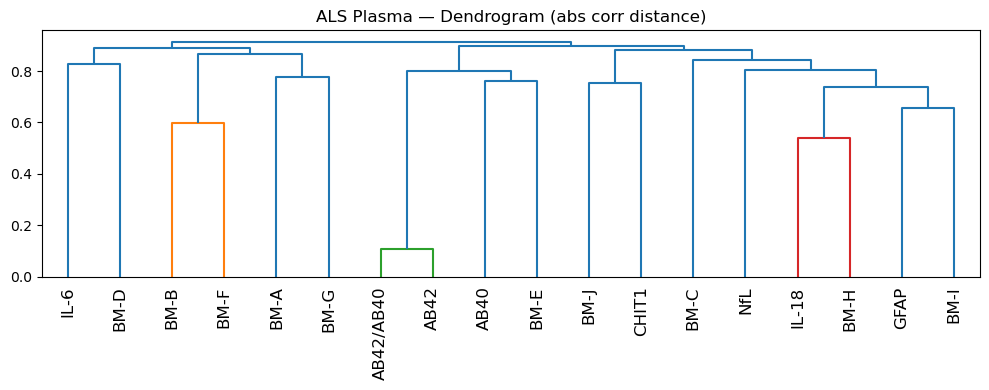

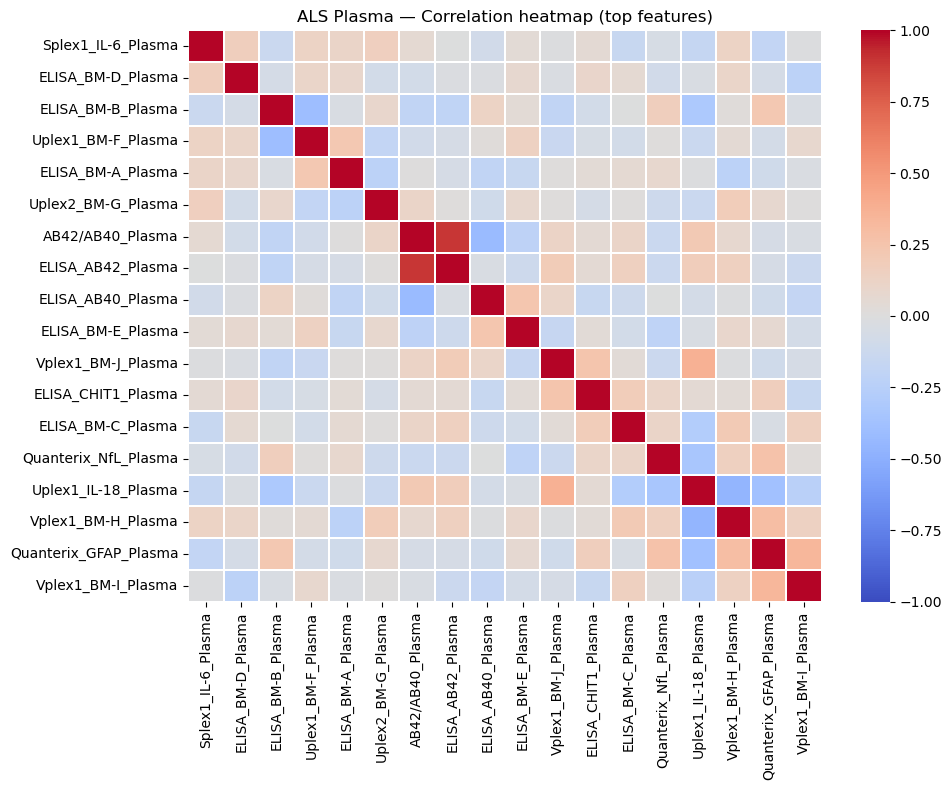

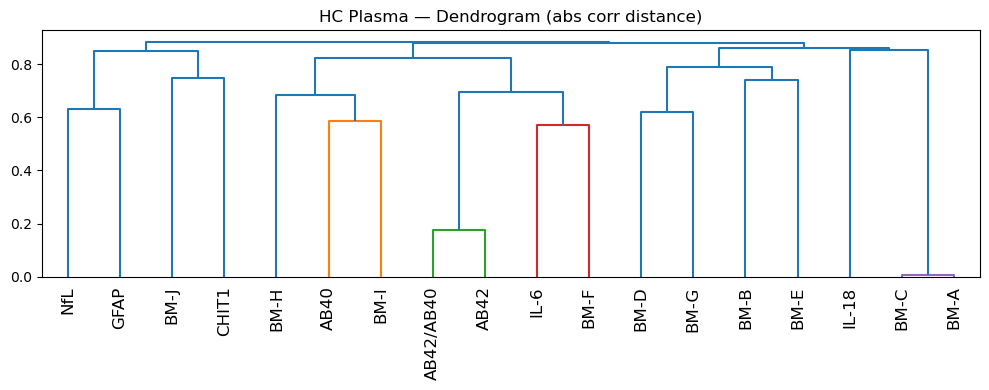

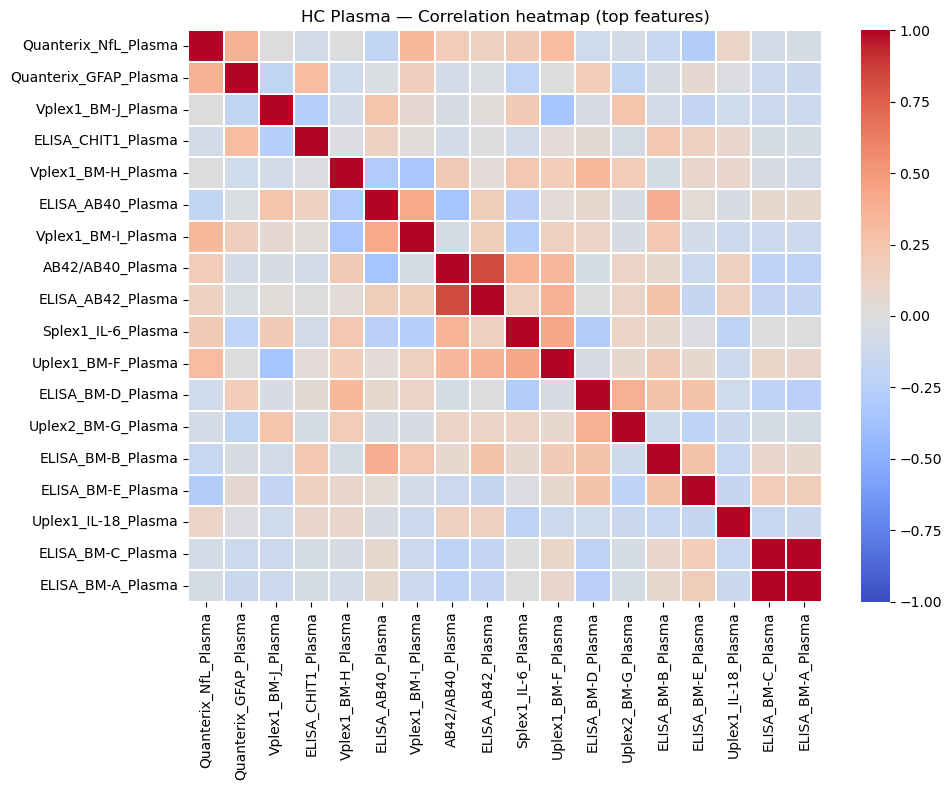

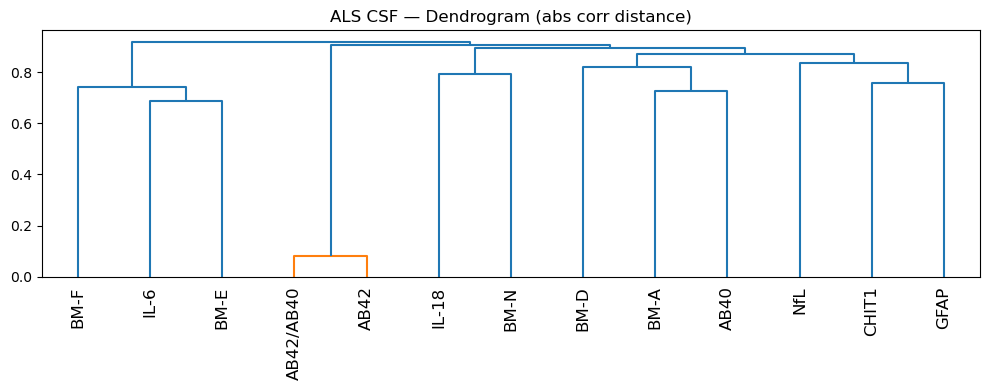

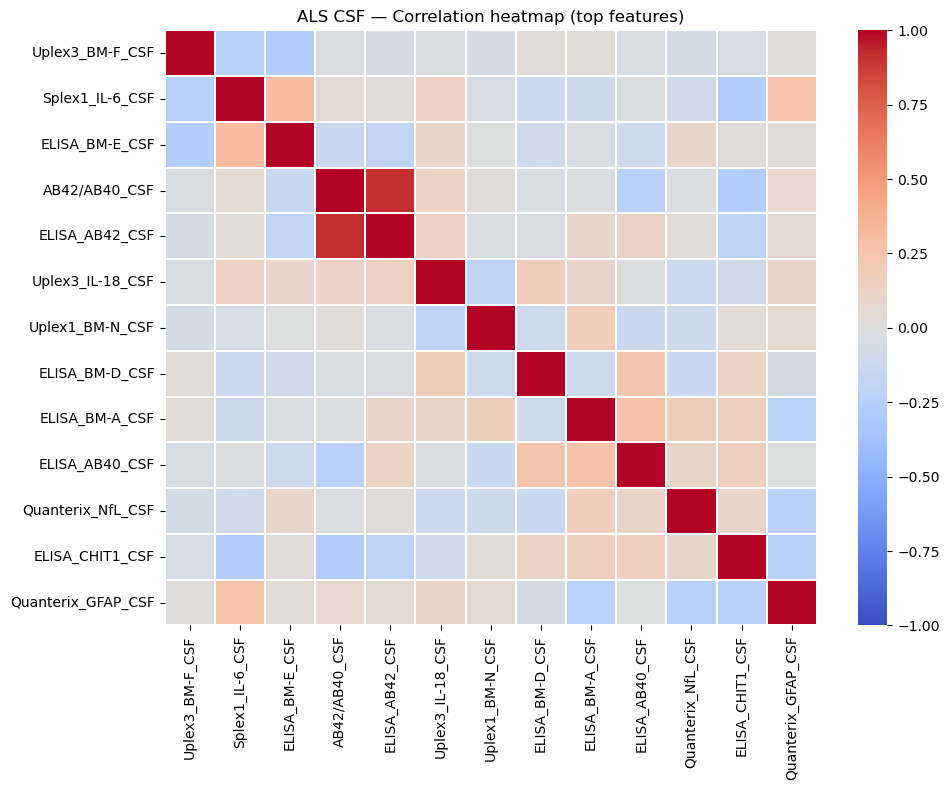

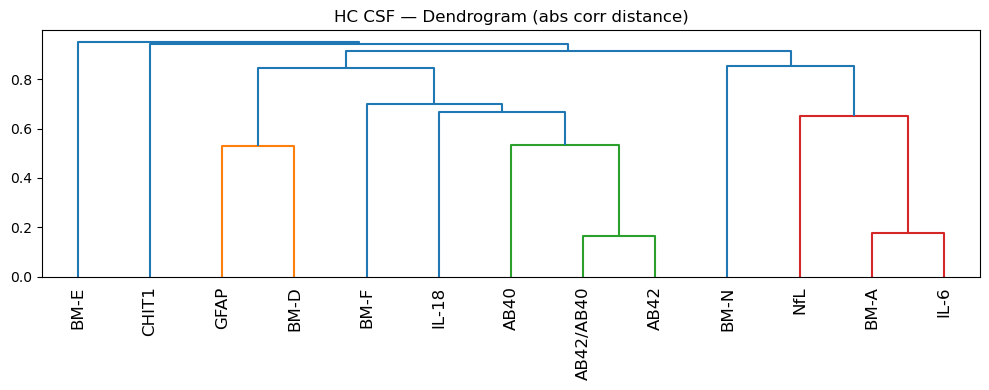

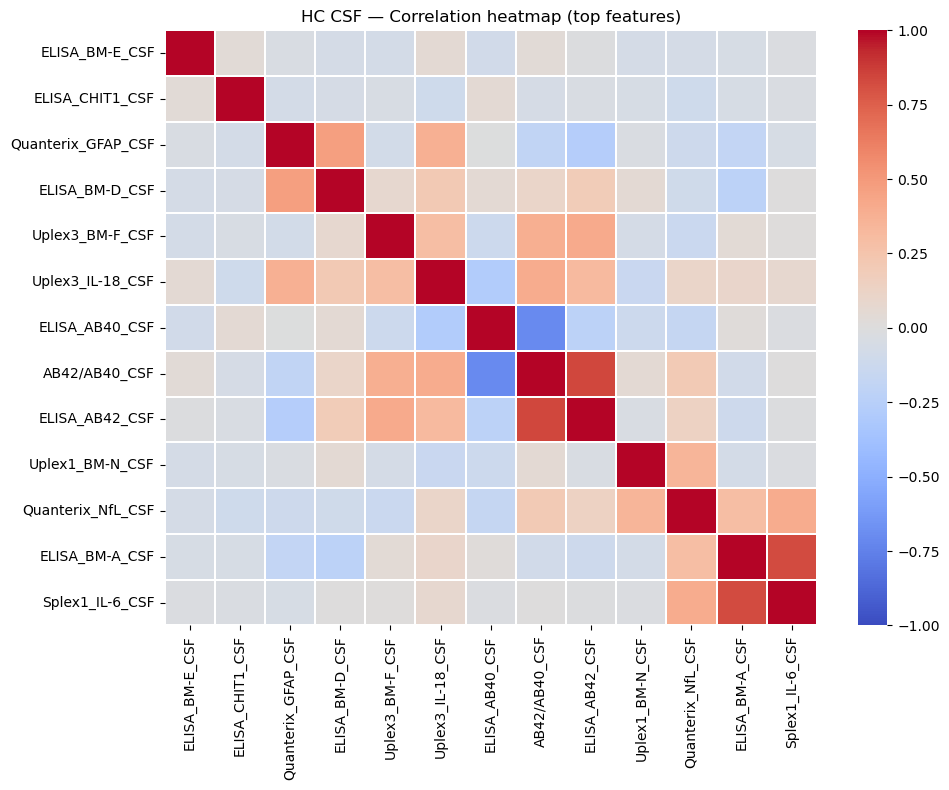

In [11]:
# Group-specific correlations
corr_plasma_als = compute_corr_matrix(build_feature_matrix(df_als, plasma_cols, exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)) if len(plasma_cols) > 1 else pd.DataFrame()
corr_plasma_hc  = compute_corr_matrix(build_feature_matrix(df_hc,  plasma_cols, exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)) if len(plasma_cols) > 1 else pd.DataFrame()
corr_csf_als    = compute_corr_matrix(build_feature_matrix(df_als, csf_cols,    exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)) if len(csf_cols) > 1 else pd.DataFrame()
corr_csf_hc     = compute_corr_matrix(build_feature_matrix(df_hc,  csf_cols,    exclude_keyword=EXCLUDE_PLATFORM_KEYWORD)) if len(csf_cols) > 1 else pd.DataFrame()

plot_feature_grouping(corr_plasma_als, f"{CASE_LABEL} Plasma")
plot_feature_grouping(corr_plasma_hc,  f"{CONTROL_LABEL} Plasma")
plot_feature_grouping(corr_csf_als,    f"{CASE_LABEL} CSF")
plot_feature_grouping(corr_csf_hc,     f"{CONTROL_LABEL} CSF")

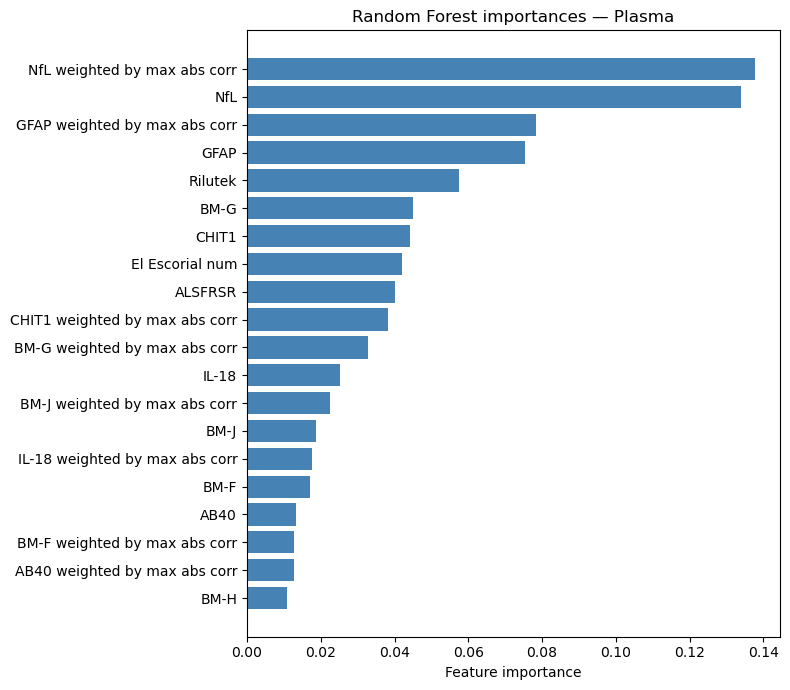

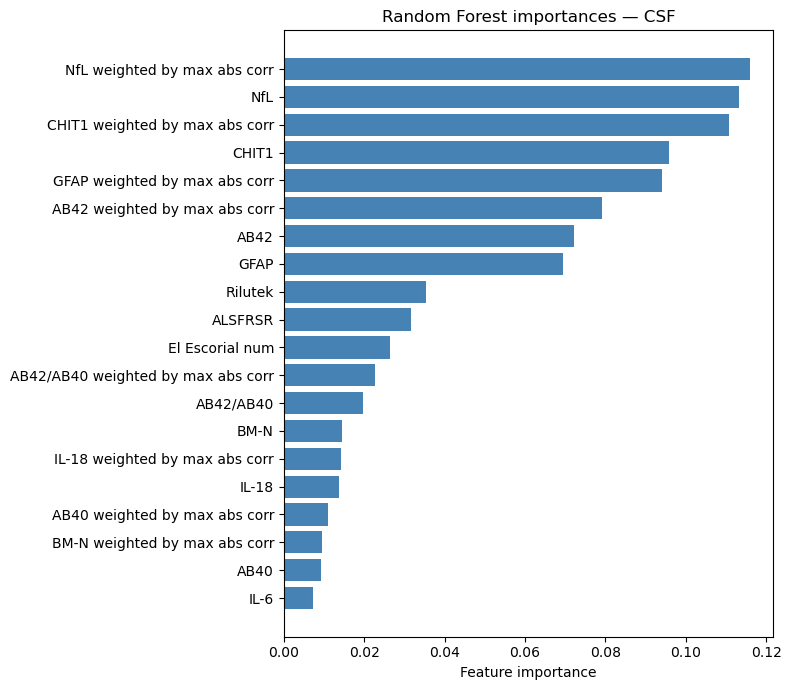

In [12]:
# Feature importance bar plots
def plot_importance(importances, title, top_n=20):
    top = importances.head(top_n)[::-1]
    plt.figure(figsize=(8, max(4, 0.35 * len(top))))
    plt.barh(clean_labels(top.index), top.values, color="steelblue")
    plt.xlabel("Feature importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

if not corr_plasma_full.empty:
    plot_importance(importances_p, f"Random Forest importances — Plasma")
if not corr_csf_full.empty:
    plot_importance(importances_c, f"Random Forest importances — CSF")

## 6 · Alluvial Plots — Cluster Reassignment (HC → ALS)

Clusters top features by correlation structure in HC vs ALS,
then visualises how analytes move between clusters.

In [13]:
def cut_clusters(corr, top_n=TOP_N_FEATURES, k=N_FAMILIES):
    """Cluster top features and return (feature_list, assignment_dict)."""
    if corr is None or corr.empty or corr.shape[1] < 2:
        return [], {}
    strength = corr.abs().apply(lambda s: s.drop(s.name).sum(), axis=0)
    top_feats = list(strength.sort_values(ascending=False).index[:top_n])
    corr_sub = corr.loc[top_feats, top_feats]
    dist = 1 - corr_sub.fillna(0).abs()
    linkage_mat = linkage(squareform(dist.values, checks=False), method="average")
    cl = fcluster(linkage_mat, t=k, criterion="maxclust")
    assignments = {feat: int(cl[i]) for i, feat in enumerate(top_feats)}
    return top_feats, assignments


def build_flows(assign_left, assign_right):
    """Build flow DataFrame from two cluster assignment dicts."""
    common = sorted(set(assign_left.keys()) & set(assign_right.keys()))
    rows = []
    for a in common:
        rows.append({
            "analyte": a,
            "analyte_label": clean_label(a),
            "left_cluster": assign_left[a],
            "right_cluster": assign_right[a]
        })
    return pd.DataFrame(rows)


def plot_alluvial(flows, left_label=CONTROL_LABEL, right_label=CASE_LABEL,
                  title="", min_flow_size=MIN_FLOW_SIZE, alpha=0.85,
                  show_side_labels=True):
    """Alluvial/Sankey plot showing cluster reassignment."""
    if flows is None or flows.empty:
        print(f"{title}: No overlapping analytes to plot.")
        return

    PALETTE = [
        "#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B",
        "#EECA3B", "#B279A2", "#FF9DA6", "#9C755F", "#BAB0AC"
    ]

    def cluster_color(cid):
        return PALETTE[(cid - 1) % len(PALETTE)]

    left_counts = flows.groupby("left_cluster")["analyte"].count().sort_index()
    right_counts = flows.groupby("right_cluster")["analyte"].count().sort_index()

    pair_counts = (flows.groupby(["left_cluster", "right_cluster"])["analyte"]
                   .count().reset_index().rename(columns={"analyte": "count"}))
    pair_counts = pair_counts[pair_counts["count"] >= min_flow_size]
    total = max(left_counts.sum(), right_counts.sum())

    def stack_positions(counts):
        y0 = 0.0
        pos = {}
        for cid, c in counts.items():
            h = c / total if total > 0 else 0
            pos[cid] = (y0, y0 + h)
            y0 += h
        return pos

    left_pos = stack_positions(left_counts)
    right_pos = stack_positions(right_counts)

    pair_counts = pair_counts.sort_values(["left_cluster", "right_cluster"]).reset_index(drop=True)
    left_offsets = {cid: left_pos[cid][0] for cid in left_counts.index}
    right_offsets = {cid: right_pos[cid][0] for cid in right_counts.index}

    bar_width = 0.04
    x_left_bar, x_right_bar = 0.06, 0.90
    curvature_k = 0.20
    gap = 0.002
    n_curve_samples = 120

    def cubic_bezier(x0, y0, cx0, cy0, cx1, cy1, x1, y1, n=n_curve_samples):
        t = np.linspace(0, 1, n)
        bx = ((1-t)**3)*x0 + 3*((1-t)**2)*t*cx0 + 3*(1-t)*(t**2)*cx1 + (t**3)*x1
        by = ((1-t)**3)*y0 + 3*((1-t)**2)*t*cy0 + 3*(1-t)*(t**2)*cy1 + (t**3)*y1
        return bx, by

    fig, ax = plt.subplots(figsize=(12, 7))

    # Draw bars
    for cid, (y0, y1) in left_pos.items():
        ax.add_patch(plt.Rectangle((x_left_bar, y0), bar_width, y1-y0,
                     facecolor=cluster_color(cid), edgecolor="#444444"))
        ax.text(-0.10, (y0+y1)/2, f"{left_label} family {cid}",
                va="center", ha="right", fontsize=9, color="#222222")

    for cid, (y0, y1) in right_pos.items():
        ax.add_patch(plt.Rectangle((x_right_bar, y0), bar_width, y1-y0,
                     facecolor=cluster_color(cid), edgecolor="#444444"))

    # Draw flows
    xL = x_left_bar + bar_width
    xR = x_right_bar
    cx0 = xL + curvature_k * (xR - xL)
    cx1 = xR - curvature_k * (xR - xL)

    for _, row in pair_counts.iterrows():
        lc = int(row["left_cluster"])
        rc = int(row["right_cluster"])
        count = int(row["count"])
        h = count / total if total > 0 else 0
        if h <= 0:
            continue

        h_eff = max(h - gap, 0)
        ly0 = left_offsets[lc]
        ly1 = ly0 + h_eff
        left_offsets[lc] = ly1 + gap

        ry0 = right_offsets[rc]
        ry1 = ry0 + h_eff
        right_offsets[rc] = ry1 + gap

        color = cluster_color(lc)
        bx1, by1 = cubic_bezier(xL, ly1, cx0, ly1, cx1, ry1, xR, ry1)
        bx2, by2 = cubic_bezier(xR, ry0, cx1, ry0, cx0, ly0, xL, ly0)

        xs = np.concatenate([bx1, bx2])
        ys = np.concatenate([by1, by2])
        ax.fill(xs, ys, color=color, alpha=alpha, linewidth=0)
        ax.plot(bx1, by1, color=(0,0,0,0.15), lw=0.5)
        ax.plot(bx2, by2, color=(0,0,0,0.15), lw=0.5)

    # Side labels
    if show_side_labels:
        for cid, dfc in flows.groupby("left_cluster"):
            y0, y1 = left_pos[cid]
            n = len(dfc)
            if n > 0:
                ys = np.linspace(y0+0.01, y1-0.01, n)
                for y, a in zip(ys, dfc["analyte_label"].tolist()):
                    ax.text(-0.065, y, a, va="center", ha="left",
                            fontsize=9, color=cluster_color(cid), fontweight="medium")

        for cid, dfc in flows.groupby("right_cluster"):
            y0, y1 = right_pos[cid]
            n = len(dfc)
            if n > 0:
                ys = np.linspace(y0+0.01, y1-0.01, n)
                labels = dfc["analyte_label"].tolist()
                left_clusters = dfc["left_cluster"].astype(int).tolist()
                right_clusters = dfc["right_cluster"].astype(int).tolist()
                for y, a, lc, rc in zip(ys, labels, left_clusters, right_clusters):
                    rcol = cluster_color(rc)
                    ax.text(1.065, y, a, va="center", ha="right",
                            fontsize=9, color=rcol, fontweight="medium")
                    if lc != rc:
                        lcol = cluster_color(lc)
                        ax.text(1.069, y, "*", va="center", ha="left",
                                fontsize=18, color=lcol, fontweight="bold")

    ax.set_xlim(-0.20, 1.20)
    ax.set_ylim(0.0, 1.0)
    ax.axis("off")
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()

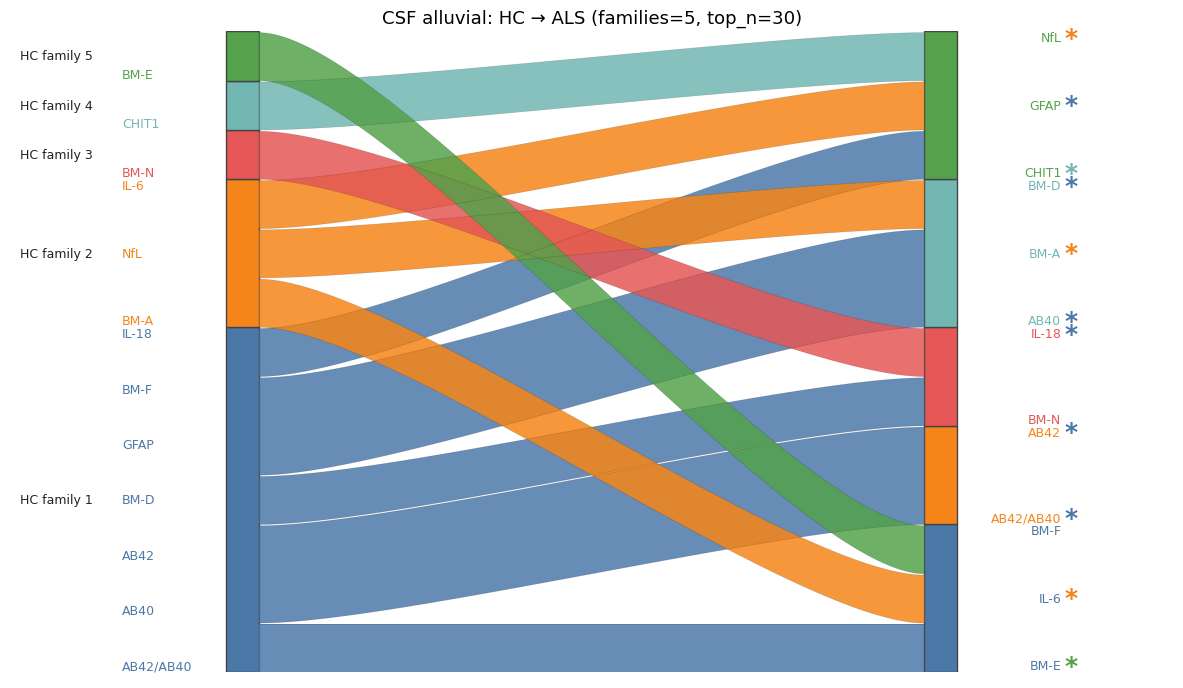

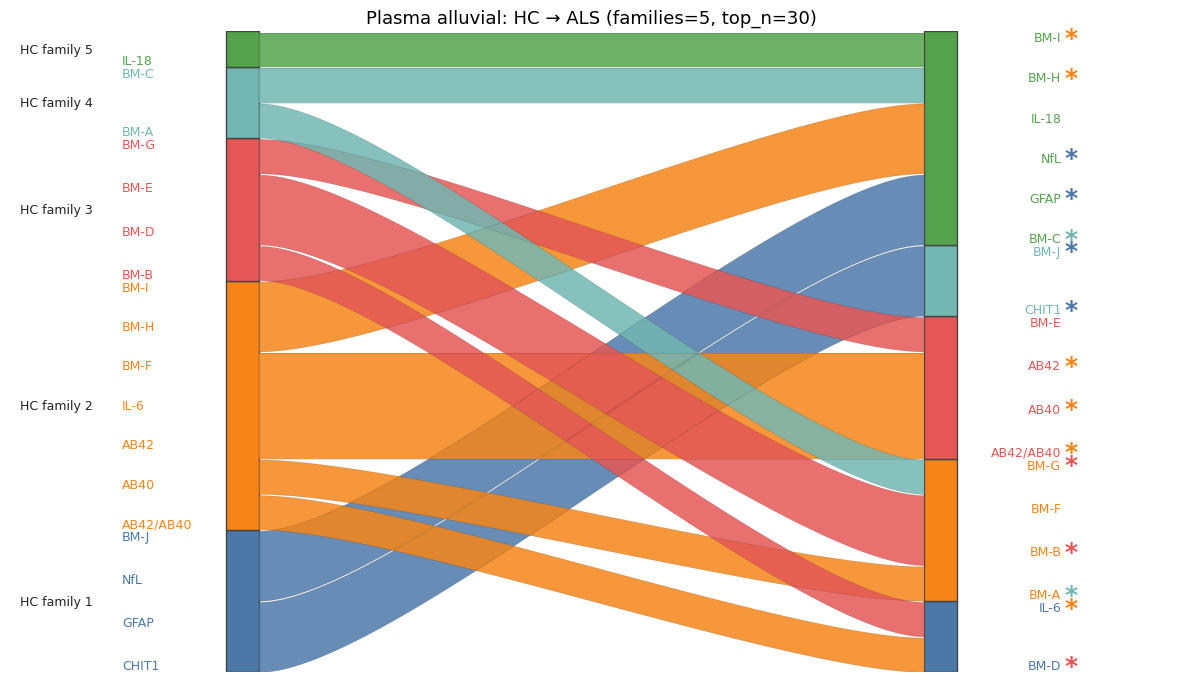

In [14]:
# Build clusters for CSF and Plasma: HC vs ALS
if not corr_csf_hc.empty and not corr_csf_als.empty:
    _, csf_assign_hc  = cut_clusters(corr_csf_hc,  top_n=TOP_N_FEATURES, k=N_FAMILIES)
    _, csf_assign_als = cut_clusters(corr_csf_als, top_n=TOP_N_FEATURES, k=N_FAMILIES)
    csf_flows = build_flows(csf_assign_hc, csf_assign_als)
    plot_alluvial(csf_flows, title=f"CSF alluvial: {CONTROL_LABEL} → {CASE_LABEL} (families={N_FAMILIES}, top_n={TOP_N_FEATURES})")

if not corr_plasma_hc.empty and not corr_plasma_als.empty:
    _, pl_assign_hc  = cut_clusters(corr_plasma_hc,  top_n=TOP_N_FEATURES, k=N_FAMILIES)
    _, pl_assign_als = cut_clusters(corr_plasma_als, top_n=TOP_N_FEATURES, k=N_FAMILIES)
    pl_flows = build_flows(pl_assign_hc, pl_assign_als)
    plot_alluvial(pl_flows, title=f"Plasma alluvial: {CONTROL_LABEL} → {CASE_LABEL} (families={N_FAMILIES}, top_n={TOP_N_FEATURES})")

---
**End of pipeline.** All analyses complete.